# BENCHMARK 1

Comparativa de los siguientes modelos con el datasets PASCAL VOC:
- U-NET
- SegFormer
- SegNext
- SAM3 -> (Caso especial) Generalización.

#### Importación de paquetes

In [1]:
import os
import time
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import VOCSegmentation

import albumentations as A                      
#from torchvision import transforms

import cv2
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F
from tqdm.notebook import tqdm
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.segmentation import MeanIoU

import segmentation_models_pytorch as smp
from transformers import SegformerForSemanticSegmentation




#### Configuración global

In [2]:
CONFIG = {
    "epochs": 3,                                   # N° de pasadas del dataset completo
    "batch": 4,                                     # N° de imágenes por paso
    "lr": 1e-4,                                     # Ratio de aprendizaje.
    "weight_decay": 1e-4,                           # Anti-overfitting
    "num_clases": 21,                               # Clases del dataset PascalVoc
    "img_size": 512,                                # Resolución de la imagen de entrada 512x512
    "seed": 42,                                     # Semilla para reproducibilidad
    "data": "../data/",                             # Ruta dataset
    "checkpoint_dir": "../checkpoints/"             # Ruta chechpoint
}

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

#### GPU Info ####
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Usando: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


#### Transformación para las imágenes de entrenamiento y de validación.

In [3]:
transform_train = A.Compose([
    A.Resize(CONFIG["img_size"], CONFIG["img_size"],
             interpolation=cv2.INTER_LINEAR,
             mask_interpolation=cv2.INTER_NEAREST),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

transform_val = A.Compose([
    A.Resize(CONFIG["img_size"], CONFIG["img_size"],
             interpolation=cv2.INTER_LINEAR,
             mask_interpolation=cv2.INTER_NEAREST),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

#### Dataset PASCAL (Pattern Analysis, Statistical Modelling and Computational Learning) VOC (Visual Object Classes)

In [4]:
class Dataset_VOC(Dataset):

    def __init__(self, root, conjunto="train", transform=None):
        self.dataset = VOCSegmentation(
            root=root,
            year="2012",
            image_set=conjunto,
            download=True
        )
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, index:int):
        image, mask = self.dataset[index]

        image = np.array(image)
        mask = np.array(mask)

        mask[mask == 255] = 0

        if self.transform:
            t = self.transform(image=image,mask=mask)
            image = t["image"]
            mask = t["mask"].long()

        return image, mask

In [5]:
# Crear datasets
train_data = Dataset_VOC(CONFIG["data"], "train", transform_train)
val_data = Dataset_VOC(CONFIG["data"], "val", transform_val)

Creación de DataLoader para entrenamiento y para la validación.

In [6]:
train_loader = DataLoader(
    train_data,                                         
    batch_size=CONFIG["batch"],
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=CONFIG["batch"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [7]:
print(f"N° imágenes de entrenamiento: {len(train_data)} imágenes | {len(train_loader)} batches")
print(f"N° imágenes de validación:    {len(val_data)} imágenes | {len(val_loader)} batches")

N° imágenes de entrenamiento: 1464 imágenes | 366 batches
N° imágenes de validación:    1449 imágenes | 363 batches


En la siguiente celda se definen las clases del dataset Pascal Voc.

- Hay 20 clases de objetos + 1 para el fondo.


In [8]:
VOC_CLASES = [
    "background"
    "aeroplane", "bicycle", "bird", "boat", "bottle", "bus", "car",
    "cat", "chair", "cow", "diningtable", "dog", "horse", "motorbike",
    "person", "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

In [9]:
COLORMAP = [
    [0,0,0],       [128,0,0],     [0,128,0],     [128,128,0],
    [0,0,128],     [128,0,128],   [0,128,128],   [128,128,128],
    [64,0,0],      [192,0,0],     [64,128,0],    [192,128,0],
    [64,0,128],    [192,0,128],   [64,128,128],  [192,128,128],
    [0,64,0],      [128,64,0],    [0,192,0],     [128,192,0],
    [0,64,128]
]

In [10]:
def colorear_mascara(mask):
    mask_color = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls, color in enumerate(COLORMAP):
        mask_color[mask == cls] = color
    return mask_color

def desnormalizar(tensor):
    mean = torch.tensor(MEAN).view(3,1,1)
    std  = torch.tensor(STD).view(3,1,1)
    return (tensor * std + mean).clamp(0,1)

In [11]:

def visualizar_ejemplos(loader, n=4):
    images, masks = next(iter(loader))
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

    for i in range(n):
        img = desnormalizar(images[i]).permute(1,2,0).numpy()
        axes[0,i].imshow(img)
        axes[0,i].set_title("Imagen")
        axes[0,i].axis("off")

        axes[1,i].imshow(colorear_mascara(masks[i].numpy()))
        axes[1,i].set_title("Máscara")
        axes[1,i].axis("off")

    plt.suptitle("Ejemplos Pascal VOC 2012", fontsize=14)
    plt.tight_layout()
    plt.show()


Shape imágenes:  torch.Size([4, 3, 512, 512])
Shape máscaras:  torch.Size([4, 512, 512])
Clases únicas:   tensor([ 0,  5,  8, 11, 15, 19])


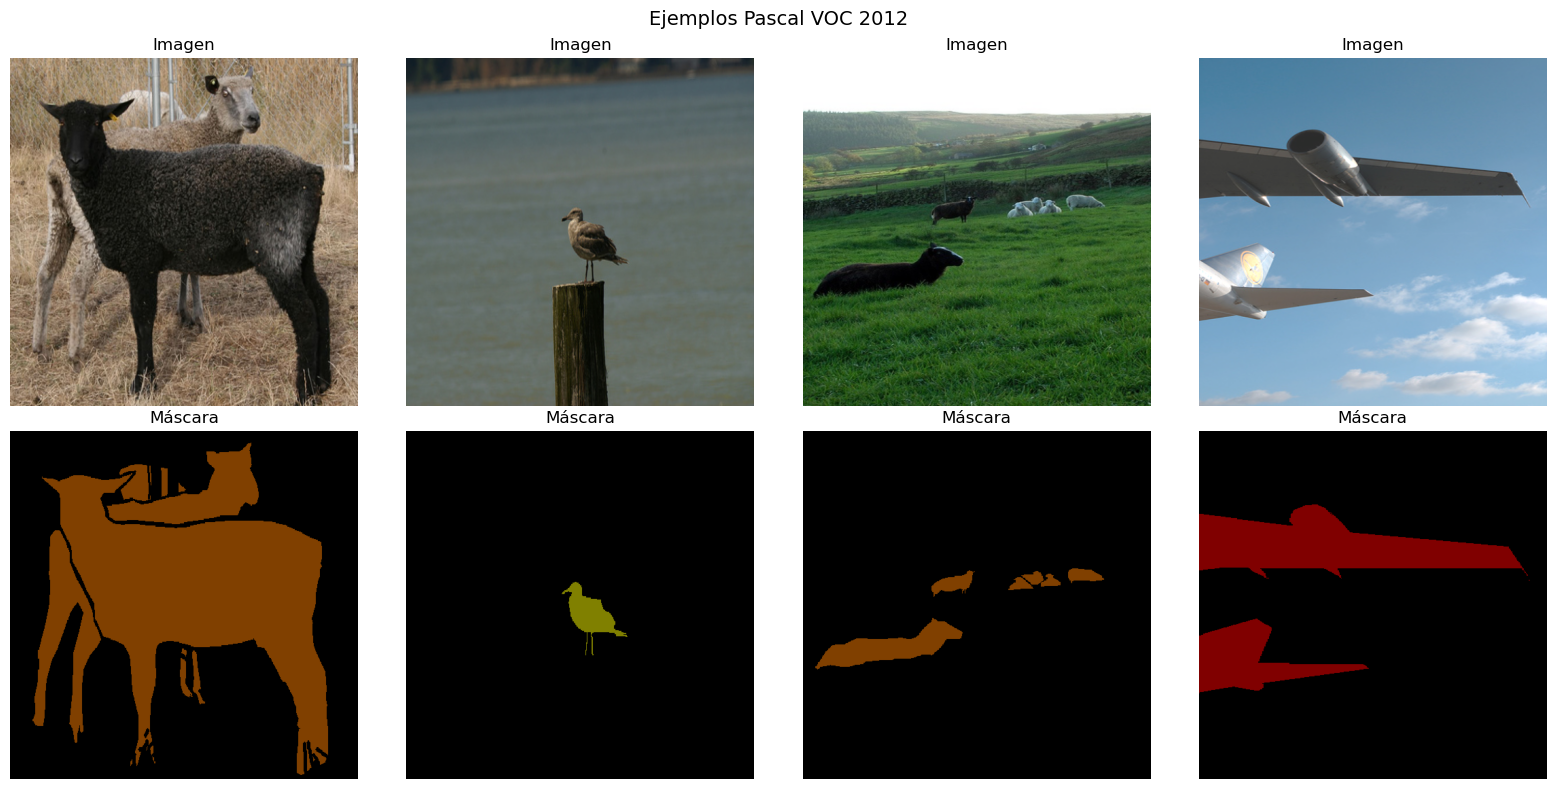

In [12]:

# Verificar shapes
images, masks = next(iter(train_loader))
print(f"Shape imágenes:  {images.shape}")   # [8, 3, 512, 512]
print(f"Shape máscaras:  {masks.shape}")    # [8, 512, 512]
print(f"Clases únicas:   {masks.unique()}")

# Visualizar
visualizar_ejemplos(train_loader)

### Definir modelos

In [13]:
# ── U-Net ──────────────────────────────────────
unet = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=CONFIG["num_clases"]
)

# ── Funciones forward ──────────────────────────
def forward_unet(model, images):
    return model(images)

print(f"U-Net params: {sum(p.numel() for p in unet.parameters())/1e6:.1f}M")

print("\nModelo U-Net cargado")

U-Net params: 32.5M

Modelo U-Net cargado


In [ ]:

# ── SegFormer ──────────────────────────────────
segformer = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b2",
    num_labels=CONFIG["num_clases"],
    ignore_mismatched_sizes=True
)
print(f"SegFormer params: {sum(p.numel() for p in segformer.parameters())/1e6:.1f}M")



def forward_segformer(model, images):
    outputs = model(pixel_values=images)
    return F.interpolate(
        outputs.logits,
        size=(CONFIG["img_size"], CONFIG["img_size"]),
        mode="bilinear",
        align_corners=False
    )

print("\nModelo SegFormer cargado")

KeyError: 'num_classes'

In [ ]:
from mmseg.apis import init_model

segnext = init_model(
    "configs/segnext/mi_segnext_voc.py",
    "checkpoints/segnext_pretrained.pth",
    device=device
)

def forward_segnext(model, images):
    outputs = model(images)
    if outputs.shape[-1] != CONFIG["img_size"]:
        outputs = F.interpolate(
            outputs,
            size=(CONFIG["img_size"], CONFIG["img_size"]),
            mode="bilinear",
            align_corners=False
        )
    return outputs

### Definición de la función de pérdida

In [14]:
class DiceCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = smp.losses.DiceLoss(
            mode="multiclass",
            ignore_index=0
        )
        self.ce = nn.CrossEntropyLoss(ignore_index=255)

    def forward(self, pred, target):
        return 0.5 * self.dice(pred, target) + 0.5 * self.ce(pred, target)

loss_fn = DiceCELoss()
print("Función de pérdida definida")

Función de pérdida definida


### Bucle de entrenamiento

In [19]:
def entrenar_modelo(modelo, nombre, forward_fn):

    modelo = modelo.to(device)
    writer  = SummaryWriter(log_dir=f"../logs/{nombre}")
    miou_fn = MeanIoU(
        num_classes=CONFIG["num_clases"]
    ).to(device)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, modelo.parameters()),
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=CONFIG["epochs"],
        eta_min=1e-6
    )

    historial = {
        "loss_train": [],
        "miou_val":   []
    }
    mejor_miou = 0.0

    for epoch in range(CONFIG["epochs"]):

        # ── Train ───────────────────────────────────
        modelo.train()
        loss_total = 0

        pbar = tqdm(
            train_loader,
            desc=f"[{nombre}] Epoch {epoch+1}/{CONFIG['epochs']}",
            leave=False
        )

        for images, masks in pbar:
            images = images.to(device)
            masks  = masks.to(device)

            optimizer.zero_grad()
            preds = forward_fn(modelo, images)
            loss  = loss_fn(preds, masks)
            loss.backward()
            optimizer.step()

            loss_total += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        loss_media = loss_total / len(train_loader)

        # ── Validación ──────────────────────────────
        modelo.eval()
        miou_fn.reset()

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks  = masks.to(device)
                preds  = forward_fn(modelo, images).argmax(dim=1)
                miou_fn.update(preds, masks)

        miou_val = miou_fn.compute().item()
        scheduler.step()

        # ── Guardar historial ───────────────────────
        historial["loss_train"].append(loss_media)
        historial["miou_val"].append(miou_val)

        # ── TensorBoard ─────────────────────────────
        writer.add_scalar("Loss/train", loss_media, epoch)
        writer.add_scalar("mIoU/val",   miou_val,   epoch)
        writer.add_scalar("LR",
            optimizer.param_groups[0]["lr"], epoch)

        print(f"[{nombre}] Epoch {epoch+1:02d} | "
              f"Loss: {loss_media:.4f} | "
              f"mIoU: {miou_val*100:.2f}%")

        # ── Guardar mejor modelo ─────────────────────
        if miou_val > mejor_miou:
            mejor_miou = miou_val
            torch.save(
                modelo.state_dict(),
                f"{CONFIG['checkpoint_dir']}{nombre}_best.pth"
            )
            print(f" Guardado: {mejor_miou*100:.2f}%")

    writer.close()
    print(f"\n{nombre} completado | Mejor mIoU: {mejor_miou*100:.2f}%")
    return mejor_miou, historial

In [21]:
print(CONFIG["checkpoint_dir"])  # debe mostrar ../checkpoints/

../checkpoints/


In [22]:
# Entrenar U-net
miou_unet, hist_unet = entrenar_modelo(
    unet, "unet", forward_unet
)

[unet] Epoch 1/3:   0%|          | 0/366 [00:00<?, ?it/s]

[unet] Epoch 01 | Loss: 0.9639 | mIoU: 24.37%
 Guardado: 24.37%


[unet] Epoch 2/3:   0%|          | 0/366 [00:00<?, ?it/s]

[unet] Epoch 02 | Loss: 0.5769 | mIoU: 31.39%
 Guardado: 31.39%


[unet] Epoch 3/3:   0%|          | 0/366 [00:00<?, ?it/s]

[unet] Epoch 03 | Loss: 0.5031 | mIoU: 33.61%
 Guardado: 33.61%

unet completado | Mejor mIoU: 33.61%


In [ ]:
# Entrenar SegFormer
miou_segformer, hist_segformer = entrenar_modelo(
    segformer, "segformer", forward_segformer
)

In [ ]:
#Entrenar SegNext
miou_segnext, hist_segnext = entrenar_modelo(
    segnext, "segnext", forward_segnext
)

### Evaluacion final

In [23]:
def evaluar_final(modelo, nombre, forward_fn):
    modelo.load_state_dict(
        torch.load(
            f"{CONFIG['checkpoint_dir']}{nombre}_best.pth",
            map_location=device
        )
    )
    modelo.eval()
    modelo = modelo.to(device)

    miou_fn  = MeanIoU(num_classes=CONFIG["num_classes"]).to(device)
    tiempos  = []
    n_params = sum(p.numel() for p in modelo.parameters()) / 1e6

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks  = masks.to(device)

            inicio = time.time()
            preds  = forward_fn(modelo, images).argmax(dim=1)
            fin    = time.time()

            tiempos.append((fin - inicio) / images.shape[0])
            miou_fn.update(preds, masks)

    miou = miou_fn.compute().item()
    fps  = 1.0 / np.mean(tiempos)

    return {
        "Modelo":      nombre,
        "mIoU (%)":    round(miou * 100, 2),
        "FPS":         round(fps, 1),
        "Params (M)":  round(n_params, 1)
    }

# Evaluar todos
resultados = []
for nombre, modelo, forward_fn in [
    ("U-Net",     unet,      forward_unet),
    ("SegFormer", segformer, forward_segformer),
    ("SegNeXt",   segnext,   forward_segnext),
]:
    res = evaluar_final(modelo, nombre, forward_fn)
    resultados.append(res)

# Tabla comparativa
df = pd.DataFrame(resultados).sort_values("mIoU (%)", ascending=False)
display(df)
df.to_csv("resultados_finales.csv", index=False)

NameError: name 'segformer' is not defined

### Visualizacion de resultados

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas mIoU
for nombre, hist in [
    ("U-Net",     hist_unet),
    ("SegFormer", hist_segformer),
    ("SegNeXt",   hist_segnext)
]:
    axes[0].plot(hist["miou_val"], label=nombre)

axes[0].set_title("mIoU Validación por Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("mIoU")
axes[0].legend()
axes[0].grid(True)

# Curvas Loss
for nombre, hist in [
    ("U-Net",     hist_unet),
    ("SegFormer", hist_segformer),
    ("SegNeXt",   hist_segnext)
]:
    axes[1].plot(hist["loss_train"], label=nombre)

axes[1].set_title("Loss Train por Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("curvas_entrenamiento.png", dpi=150)
plt.show()